# Figure 3: Zero-shot experiment results

This notebook plots the zero-shot evaluation results from:
- **Loudness order discrimination** (speech commands level)
- **Melody match** (NSynth)
- **Mandarin tone discrimination**

Results are loaded from CSVs saved by the respective zero-shot notebooks in `results_dfs/`.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import sys

sys.path.insert(0, str(Path("../").resolve()))

import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    normalize_model_name,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    get_model_groups,
    model_label,
    plot_grouped_bars,
)

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

%matplotlib inline

## Load zero-shot result CSVs

In [2]:
RESULTS_DIR = Path("results_dfs")
DEFAULT_LAYER = "relu4"


def _layer_from_filename(path):
    """Extract layer from filename like ..._results_<layer>.csv; else DEFAULT_LAYER."""
    stem = path.stem
    if "_results_" in stem:
        suffix = stem.split("_results_", 1)[-1]
        return suffix if suffix else DEFAULT_LAYER
    return DEFAULT_LAYER


def _load_task_csvs(glob_pattern):
    """Load all CSVs matching pattern, add 'layer' column, concatenate."""
    paths = sorted(RESULTS_DIR.glob(glob_pattern))
    if not paths:
        return pd.DataFrame()
    dfs = []
    for p in paths:
        df = pd.read_csv(p)
        df["layer"] = _layer_from_filename(p)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


# Loudness order (speech commands level discrimination)
speech_loudness_df = _load_task_csvs("zero_shot_speech_commands_level_discrimination_results*.csv")
# map the relu4 model names to the relufc model_name column
# get unique model and model_name values
model_name_map = {model:model_name for model, model_name in speech_loudness_df[['model', 'model_name']].dropna().drop_duplicates().values}
# map the model_name to the relufc model_name
speech_loudness_df['model_name'] = speech_loudness_df['model'].map(model_name_map)
speech_loudness_df['task'] = "Loudness order discrimination"



# Melody match (NSynth)
melody_df = _load_task_csvs("zero_shot_nsynth_melody_match_results*.csv")
melody_df['task'] = "Melody match"

# Mandarin tone discrimination
mandarin_df = _load_task_csvs("zero_shot_mandarin_tone_results*.csv")
mandarin_df['task'] = "Mandarin tone discrimination"

print(f"Speech commands: {len(speech_loudness_df)} rows (layers: {speech_loudness_df['layer'].unique().tolist() if not speech_loudness_df.empty else []})")
print(f"NSynth melody:  {len(melody_df)} rows (layers: {melody_df['layer'].unique().tolist() if not melody_df.empty else []})")
print(f"Mandarin tone: {len(mandarin_df)} rows (layers: {mandarin_df['layer'].unique().tolist() if not mandarin_df.empty else []})")

results_df = pd.concat([speech_loudness_df, melody_df, mandarin_df], ignore_index=True, axis=0)


Speech commands: 52000 rows (layers: ['relu4', 'relufc'])
NSynth melody:  124800 rows (layers: ['relu4', 'relufc'])
Mandarin tone: 51974 rows (layers: ['relu4', 'relufc'])


In [8]:
no_byola_df = results_df[results_df['model_name'] != 'byol-a']

## Plot three panels (CochDNN9 / BYOL-A)

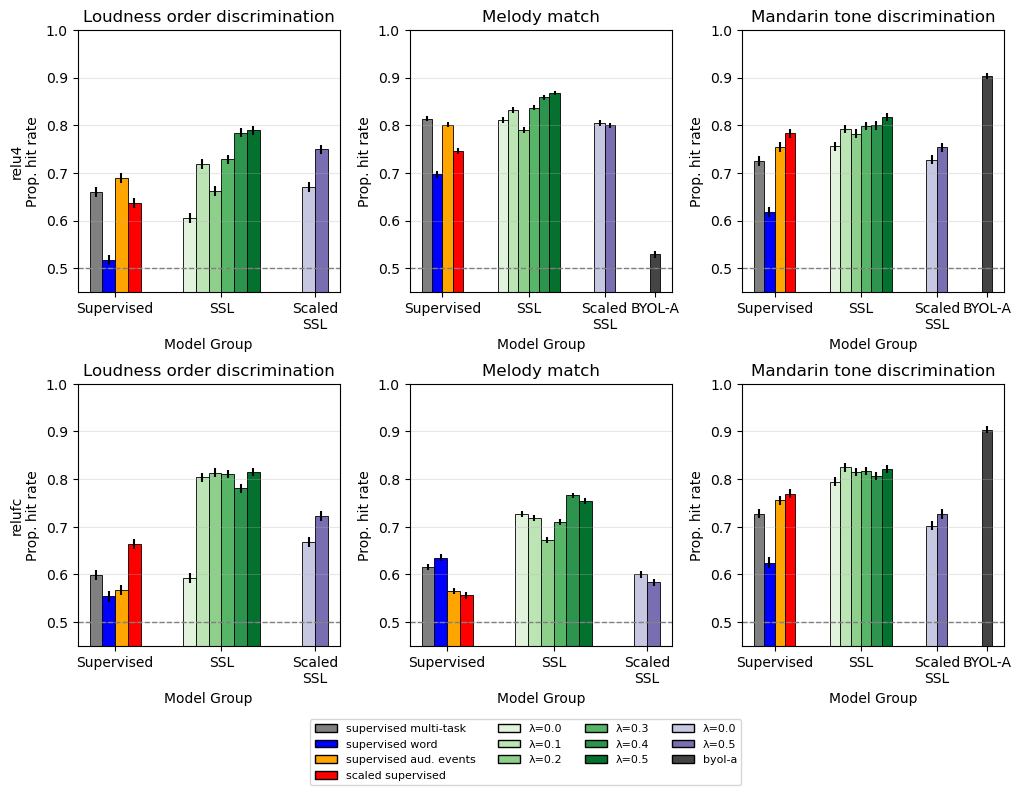

In [5]:
# Task order (columns) and value column per task
TASK_CONFIG = [
    ("Loudness order discrimination", "sqr_l2_judgement"),
    ("Melody match", "judgement_pos_lt_neg"),
    ("Mandarin tone discrimination", "sqr_l2_judgement"),
]


def _models_in_data(df):
    """Unique normalized model names present in the dataframe (in standard order)."""
    if df.empty:
        return []
    standard_order = get_standard_hue_order()
    col = "model_name" if "model_name" in df.columns else "model"
    seen = set()
    for raw in df[col].dropna().unique():
        norm = normalize_model_name(str(raw))
        if norm in standard_order:
            seen.add(norm)
    return [m for m in standard_order if m in seen]


hue_order = _models_in_data(results_df)
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)


def prepare_plot_df(df, model_col="model_name", hue_order=hue_order):
    """Normalize model names and filter to models in hue_order."""
    if df.empty:
        return df
    out = df.copy()
    out["model_name"] = out[model_col].astype(str).apply(normalize_model_name)
    return out[out["model_name"].isin(hue_order)]


# One row per layer, one column per task
layers = sorted(results_df["layer"].dropna().unique())
n_rows = len(layers)
n_cols = len(TASK_CONFIG)
base_size = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(base_size * max(1, n_cols), base_size * max(1, n_rows)))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row_idx, layer in enumerate(layers):
    for col_idx, (task_name, value_col) in enumerate(TASK_CONFIG):
        ax = axes[row_idx, col_idx]
        plot_df = prepare_plot_df(
            results_df[(results_df["layer"] == layer) & (results_df["task"] == task_name)]
        )
        if not plot_df.empty:
            plot_grouped_bars(
                ax, plot_df, value_col=value_col,
                title=task_name if row_idx == 0 else None,
                ylabel="Prop. hit rate", hue_order=hue_order, hue_dict=hue_dict,
                error_type="sem", capsize=0,
            )
        ax.set_title(task_name)
        ax.set_ylim(0.45, 1.0)
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
        ax.grid(axis="y", alpha=0.3, zorder=-1)
        if col_idx == 0:
            ax.set_ylabel(f"{layer}\nProp. hit rate" if n_rows > 1 else "Prop. hit rate")

# Single legend below all panels
legend_handles = [Patch(facecolor=hue_dict.get(m, "#444444"), edgecolor="black") for m in hue_order]
legend_labels = [model_label(m) for m in hue_order]
fig.legend(
    legend_handles, legend_labels,
    frameon=True, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, .025), ncol=4,
)
# plt.tight_layout()

# make all panels square 
ratio = 1.0 
for ax in axes.flatten():
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)

# adjust w and h space
fig.subplots_adjust(wspace=0.25, hspace=0.35)
 


## Without BYOL-A

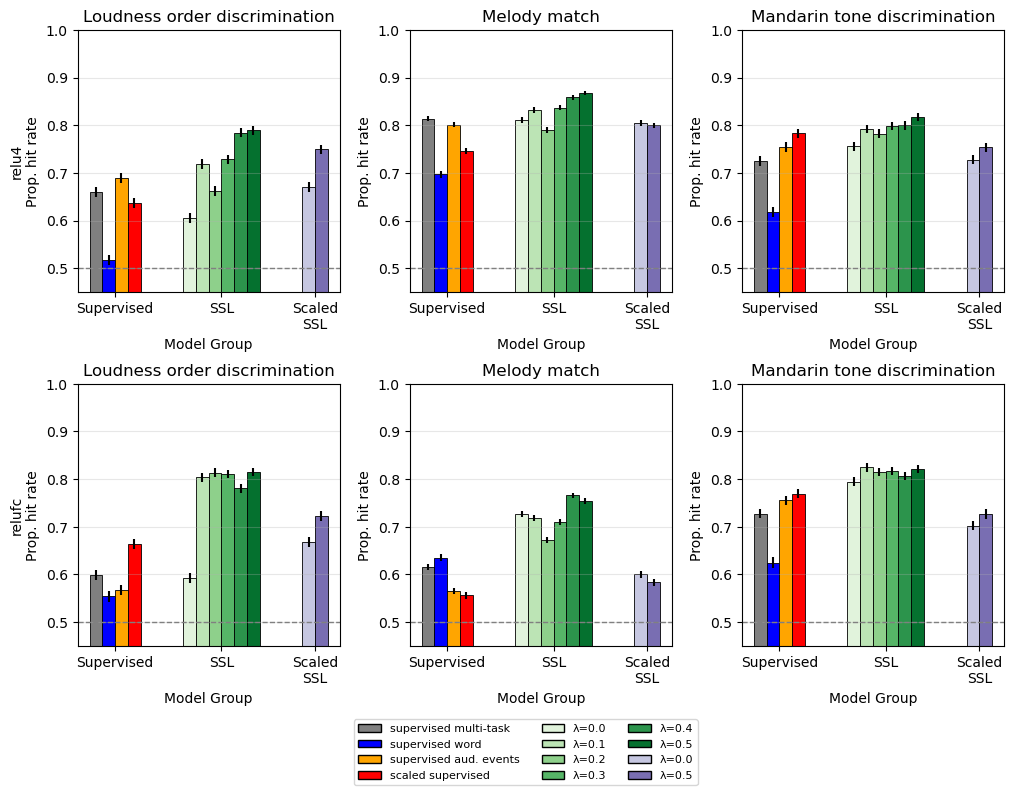

In [10]:
# Task order (columns) and value column per task
TASK_CONFIG = [
    ("Loudness order discrimination", "sqr_l2_judgement"),
    ("Melody match", "judgement_pos_lt_neg"),
    ("Mandarin tone discrimination", "sqr_l2_judgement"),
]


def _models_in_data(df):
    """Unique normalized model names present in the dataframe (in standard order)."""
    if df.empty:
        return []
    standard_order = get_standard_hue_order()
    col = "model_name" if "model_name" in df.columns else "model"
    seen = set()
    for raw in df[col].dropna().unique():
        norm = normalize_model_name(str(raw))
        if norm in standard_order:
            seen.add(norm)
    return [m for m in standard_order if m in seen]


hue_order = _models_in_data(no_byola_df)
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)


def prepare_plot_df(df, model_col="model_name", hue_order=hue_order):
    """Normalize model names and filter to models in hue_order."""
    if df.empty:
        return df
    out = df.copy()
    out["model_name"] = out[model_col].astype(str).apply(normalize_model_name)
    return out[out["model_name"].isin(hue_order)]


# One row per layer, one column per task
layers = sorted(no_byola_df["layer"].dropna().unique())
n_rows = len(layers)
n_cols = len(TASK_CONFIG)
base_size = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(base_size * max(1, n_cols), base_size * max(1, n_rows)))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row_idx, layer in enumerate(layers):
    for col_idx, (task_name, value_col) in enumerate(TASK_CONFIG):
        ax = axes[row_idx, col_idx]
        plot_df = prepare_plot_df(
            no_byola_df[(no_byola_df["layer"] == layer) & (no_byola_df["task"] == task_name)]
        )
        if not plot_df.empty:
            plot_grouped_bars(
                ax, plot_df, value_col=value_col,
                title=task_name if row_idx == 0 else None,
                ylabel="Prop. hit rate", hue_order=hue_order, hue_dict=hue_dict,
                error_type="sem", capsize=0,
            )
        ax.set_title(task_name)
        ax.set_ylim(0.45, 1.0)
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
        ax.grid(axis="y", alpha=0.3, zorder=-1)
        if col_idx == 0:
            ax.set_ylabel(f"{layer}\nProp. hit rate" if n_rows > 1 else "Prop. hit rate")

# Single legend below all panels
legend_handles = [Patch(facecolor=hue_dict.get(m, "#444444"), edgecolor="black") for m in hue_order]
legend_labels = [model_label(m) for m in hue_order]
fig.legend(
    legend_handles, legend_labels,
    frameon=True, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, .025), ncol=3,
)
# plt.tight_layout()

# make all panels square 
ratio = 1.0 
for ax in axes.flatten():
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)

# adjust w and h space
fig.subplots_adjust(wspace=0.25, hspace=0.35)
 
